In [38]:
# 1. Explore Data

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_csv("afd_parl_docs_topics.csv")

In [121]:
df.head(50)

,Unnamed: 0,parl,id,date,speaker,text,token_count,topic_id,topic_name,topic_representation,topic_probability
0,0,bt,sp19_4,2017-11-21,Tino Chrupalla,Aber auch die Grünen will ich nicht aus der Ve...,131,0,0_deutschland_co2_energiewende_kernenergie,"['deutschland', 'co2', 'energiewende', 'kernen...",1.000000
1,1,bt,sp19_4,2017-11-21,Tino Chrupalla,Mit gesunden Heimatmärkten hätten wir das Prob...,59,0,0_deutschland_co2_energiewende_kernenergie,"['deutschland', 'co2', 'energiewende', 'kernen...",0.965675
2,2,bt,sp19_9,2017-11-21,Heiko Heßenkemper,Zurück zu Siemens. Hier ist jetzt die Kraftwer...,49,-1,-1_euro_energiewende_co2_deutschland,"['euro', 'energiewende', 'co2', 'deutschland',...",0.000000
3,3,bt,sp19_14,2017-11-21,Marc Bernhard,Stattdessen führt jedoch eine von Ihnen grünäu...,40,-1,-1_euro_energiewende_co2_deutschland,"['euro', 'energiewende', 'co2', 'deutschland',...",0.000000
4,4,bt,sp19_21,2017-11-21,Karsten Hilse,Frau Präsidentin! Werte Kollegen! Offensichtli...,127,-1,-1_euro_energiewende_co2_deutschland,"['euro', 'energiewende', 'co2', 'deutschland',...",0.000000
5,5,bt,sp19_21,2017-11-21,Karsten Hilse,"Das kann auch gar nicht anders sein, weil mit ...",125,0,0_deutschland_co2_energiewende_kernenergie,"['deutschland', 'co2', 'energiewende', 'kernen...",1.000000
6,6,bt,sp19_21,2017-11-21,Karsten Hilse,Mit einem Kohleausstieg setzen wir die Deindus...,110,0,0_deutschland_co2_energiewende_kernenergie,"['deutschland', 'co2', 'energiewende', 'kernen...",1.000000
7,7,bt,sp19_21,2017-11-21,Karsten Hilse,Er gefährdet zudem absichtlich den Wohlstand u...,78,-1,-1_euro_energiewende_co2_deutschland,"['euro', 'energiewende', 'co2', 'deutschland',...",0.000000
8,8,bt,sp19_30,2017-12-12,Steffen Kotré,"Jetzt komme ich zu dem, was wir tun können, da...",128,-1,-1_euro_energiewende_co2_deutschland,"['euro', 'energiewende', 'co2', 'deutschland',...",0.000000
9,9,bt,sp19_32,2017-12-12,Armin-Paulus Hampel,"Herr Kollege Theurer, stimmen Sie den Anmerkun...",58,0,0_deutschland_co2_energiewende_kernenergie,"['deutschland', 'co2', 'energiewende', 'kernen...",0.930741


In [52]:
df.shape

(1981, 11)

In [53]:
df.columns

Index(['Unnamed: 0', 'parl', 'id', 'date', 'speaker', 'text', 'token_count',
       'topic_id', 'topic_name', 'topic_representation', 'topic_probability'],
      dtype='object')

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1981 entries, 0 to 1980
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            1981 non-null   int64  
 1   parl                  1981 non-null   object 
 2   id                    1981 non-null   object 
 3   date                  1981 non-null   object 
 4   speaker               1981 non-null   object 
 5   text                  1981 non-null   object 
 6   token_count           1981 non-null   int64  
 7   topic_id              1981 non-null   int64  
 8   topic_name            1981 non-null   object 
 9   topic_representation  1981 non-null   object 
 10  topic_probability     1981 non-null   float64
dtypes: float64(1), int64(3), object(7)
memory usage: 170.4+ KB


In [57]:
missing_rate = df.isnull().mean()
print(missing_rate)

Unnamed: 0              0.0
parl                    0.0
id                      0.0
date                    0.0
speaker                 0.0
text                    0.0
token_count             0.0
topic_id                0.0
topic_name              0.0
topic_representation    0.0
topic_probability       0.0
dtype: float64


In [138]:
count_topics = df["topic_name"].value_counts().sort_index()
count_topics.info

<bound method Series.info of topic_name
-1_euro_energiewende_co2_deutschland                                    854
0_deutschland_co2_energiewende_kernenergie                              433
1_euro_deutschland_milliarden euro_politik                              292
2_klimawandel_klima_klimawandels_wissenschaftler                        157
3_autoindustrie_synthetische kraftstoffe_elektromobilität_emissionen     72
4_wohnungen_bauen_millionen_gebäuden                                     50
5_entwicklungshilfe_vermögen_förderung_afrika                            47
6_windindustrieanlagen_windkraftanlagen_industrieanlagen_wohnhäusern     28
7_arbeitsplätze_betroffen_gewerkschaften_unternehmen deutschland         24
8_klima_demokratie_klima geschaffen_klima angst                          24
Name: count, dtype: int64>

In [139]:
count_topics.sum()

np.int64(1981)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, '-1_euro_energiewende_co2_deutschland'),
  Text(1, 0, '0_deutschland_co2_energiewende_kernenergie'),
  Text(2, 0, '1_euro_deutschland_milliarden euro_politik'),
  Text(3, 0, '2_klimawandel_klima_klimawandels_wissenschaftler'),
  Text(4, 0, '3_autoindustrie_synthetische kraftstoffe_elektromobilität_emissionen'),
  Text(5, 0, '4_wohnungen_bauen_millionen_gebäuden'),
  Text(6, 0, '5_entwicklungshilfe_vermögen_förderung_afrika'),
  Text(7, 0, '6_windindustrieanlagen_windkraftanlagen_industrieanlagen_wohnhäusern'),
  Text(8, 0, '7_arbeitsplätze_betroffen_gewerkschaften_unternehmen deutschland'),
  Text(9, 0, '8_klima_demokratie_klima geschaffen_klima angst')])

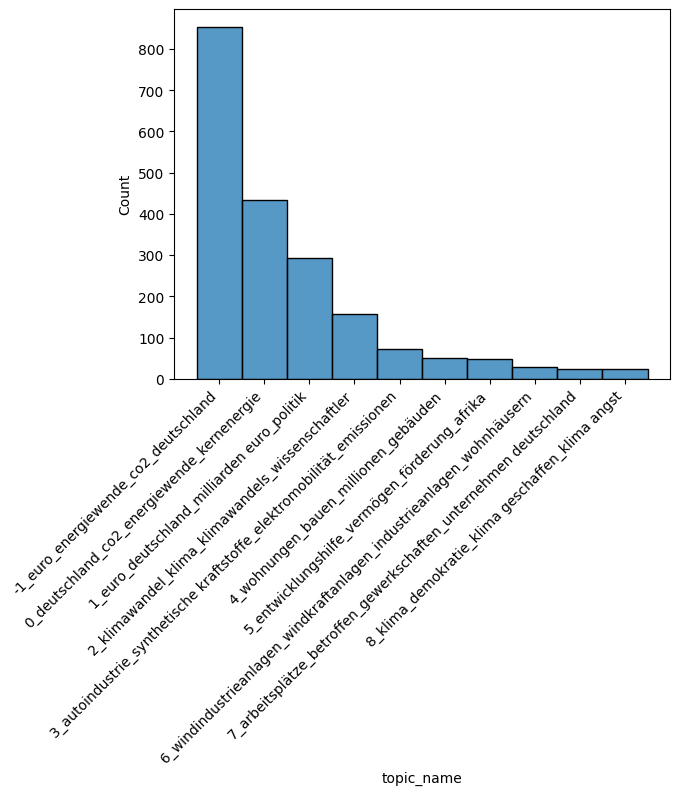

In [118]:
sns.histplot(df.sort_values(by="topic_name"), x="topic_name")
plt.xticks(rotation=45, ha='right')

In [125]:
# 2. Topic Filtering

In [127]:
topics_to_keep = [
    "-1_euro_energiewende_co2_deutschland",
    "0_deutschland_co2_energiewende_kernenergie",
    "2_klimawandel_klima_klimawandels_wissenschaftler",
    "3_autoindustrie_synthetische kraftstoffe_elektromobilität_emissionen",
    "6_windindustrieanlagen_windkraftanlagen_industrieanlagen_wohnhäusern",
    "8_klima_demokratie_klima geschaffen_klima angst"
]
df_filt = df[df["topic_name"].isin(topics_to_keep)]

In [135]:
count_topics_filt = df_filt["topic_name"].value_counts().sort_index()
count_topics_filt.info

<bound method Series.info of topic_name
-1_euro_energiewende_co2_deutschland                                    854
0_deutschland_co2_energiewende_kernenergie                              433
2_klimawandel_klima_klimawandels_wissenschaftler                        157
3_autoindustrie_synthetische kraftstoffe_elektromobilität_emissionen     72
6_windindustrieanlagen_windkraftanlagen_industrieanlagen_wohnhäusern     28
8_klima_demokratie_klima geschaffen_klima angst                          24
Name: count, dtype: int64>

In [137]:
count_topics_filt.sum()

np.int64(1568)

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, '-1_euro_energiewende_co2_deutschland'),
  Text(1, 0, '0_deutschland_co2_energiewende_kernenergie'),
  Text(2, 0, '2_klimawandel_klima_klimawandels_wissenschaftler'),
  Text(3, 0, '3_autoindustrie_synthetische kraftstoffe_elektromobilität_emissionen'),
  Text(4, 0, '6_windindustrieanlagen_windkraftanlagen_industrieanlagen_wohnhäusern'),
  Text(5, 0, '8_klima_demokratie_klima geschaffen_klima angst')])

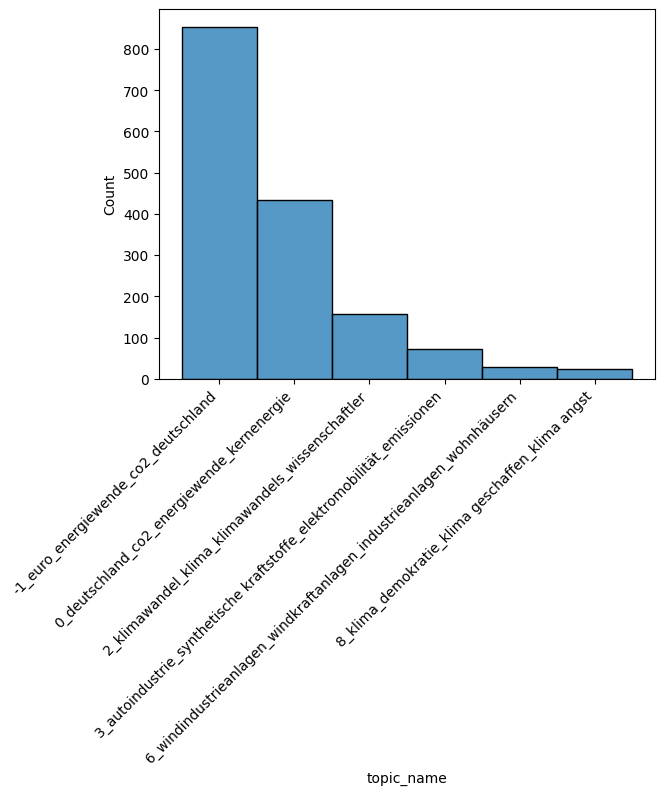

In [143]:
sns.histplot(df_filt.sort_values(by="topic_name"), x="topic_name")
plt.xticks(rotation=45, ha='right')

In [178]:
# 3. Sample Paragraphs

In [175]:
X_train, X_test = train_test_split(df_filt, train_size=150, test_size=30, random_state=42, stratify = df_filt["topic_name"])

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, '-1_euro_energiewende_co2_deutschland'),
  Text(1, 0, '0_deutschland_co2_energiewende_kernenergie'),
  Text(2, 0, '2_klimawandel_klima_klimawandels_wissenschaftler'),
  Text(3, 0, '3_autoindustrie_synthetische kraftstoffe_elektromobilität_emissionen'),
  Text(4, 0, '6_windindustrieanlagen_windkraftanlagen_industrieanlagen_wohnhäusern'),
  Text(5, 0, '8_klima_demokratie_klima geschaffen_klima angst')])

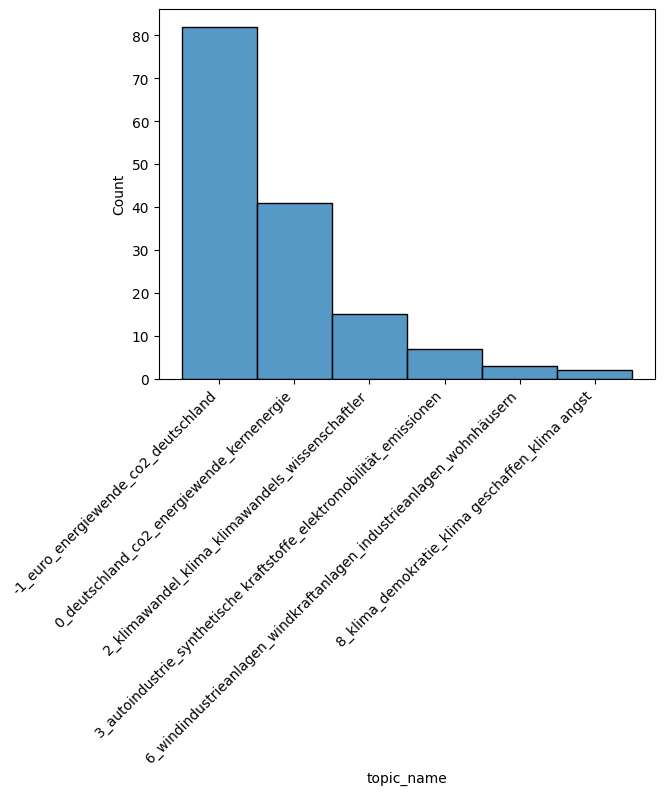

In [176]:
sns.histplot(X_train.sort_values(by="topic_name"), x="topic_name")
plt.xticks(rotation=45, ha='right')

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, '-1_euro_energiewende_co2_deutschland'),
  Text(1, 0, '0_deutschland_co2_energiewende_kernenergie'),
  Text(2, 0, '2_klimawandel_klima_klimawandels_wissenschaftler'),
  Text(3, 0, '3_autoindustrie_synthetische kraftstoffe_elektromobilität_emissionen'),
  Text(4, 0, '6_windindustrieanlagen_windkraftanlagen_industrieanlagen_wohnhäusern'),
  Text(5, 0, '8_klima_demokratie_klima geschaffen_klima angst')])

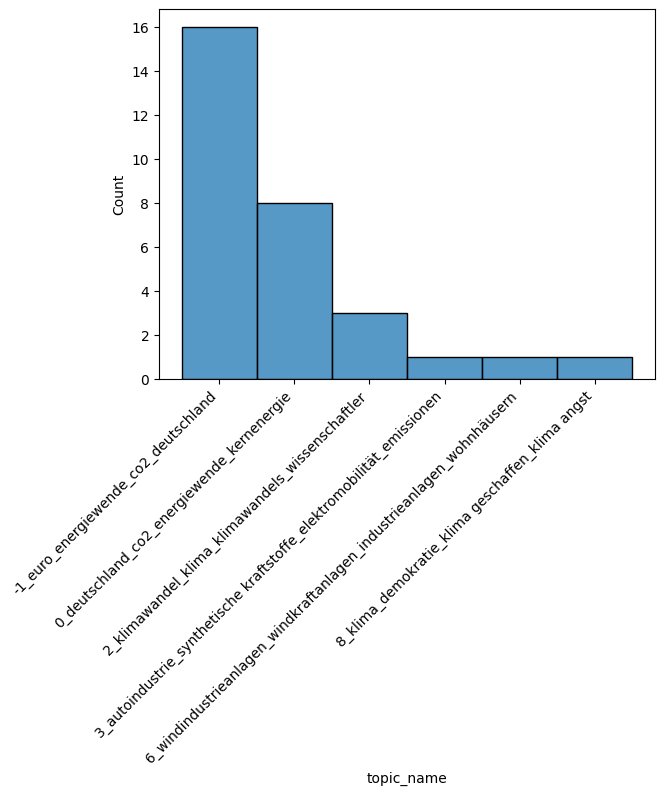

In [177]:
sns.histplot(X_test.sort_values(by="topic_name"), x="topic_name")
plt.xticks(rotation=45, ha='right')

In [179]:
X_train.to_csv("X_train.csv")

In [180]:
X_test.to_csv("X_test.csv")